Task 1: Import Required Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

Task 2: Load the Dataset

In [4]:
df = pd.read_csv('/content/Employee data.csv')

# Display first 5 rows
df.head()

,id,gender,bdate,educ,jobcat,salary,salbegin,jobtime,prevexp,minority
0,1.0,Male,1952-02-03,15,Manager,57000.0,27000.0,98.0,144.0,No
1,2.0,Male,1958-05-23,16,Clerical,40200.0,18750.0,98.0,36.0,No
2,3.0,Female,1929-07-26,12,Clerical,21450.0,12000.0,98.0,381.0,No
3,4.0,Female,1947-04-15,8,Clerical,21900.0,13200.0,98.0,190.0,No
4,5.0,Male,1955-02-09,15,Clerical,45000.0,21000.0,98.0,138.0,No


Task 3: Understand the Dataset

In [5]:
# Shape of dataset
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
df.info()

Rows and Columns: (474, 10)

Columns:
Index(['id', 'gender', 'bdate', 'educ', 'jobcat', 'salary', 'salbegin',
       'jobtime', 'prevexp', 'minority'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        474 non-null    float64
 1   gender    474 non-null    object 
 2   bdate     473 non-null    object 
 3   educ      474 non-null    int64  
 4   jobcat    474 non-null    object 
 5   salary    474 non-null    float64
 6   salbegin  474 non-null    float64
 7   jobtime   474 non-null    float64
 8   prevexp   474 non-null    object 
 9   minority  474 non-null    object 
dtypes: float64(4), int64(1), object(5)
memory usage: 37.2+ KB


Task 4: Check Missing Values

In [6]:
# Missing values in each column
df.isnull().sum()

,0
id,0
gender,0
bdate,1
educ,0
jobcat,0
salary,0
salbegin,0
jobtime,0
prevexp,0
minority,0


Task 5: Statistical Summary

In [7]:
# Summary statistics
df.describe()

,id,educ,salary,salbegin,jobtime
count,474.000000,474.000000,474.000000,474.000000,474.000000
mean,237.500000,13.491561,34419.567511,17016.086498,81.109705
std,136.976275,2.884846,17075.661465,7870.638154,10.060945
min,1.000000,8.000000,15750.000000,9000.000000,63.000000
25%,119.250000,12.000000,24000.000000,12487.500000,72.000000
50%,237.500000,12.000000,28875.000000,15000.000000,81.000000
75%,355.750000,15.000000,36937.500000,17490.000000,90.000000
max,474.000000,21.000000,135000.000000,79980.000000,98.000000


In [8]:
df.describe(include='object')

,gender,bdate,jobcat,prevexp,minority
count,474,473,474,474,474
unique,2,461,3,208,2
top,Male,1961-05-25,Clerical,missing,No
freq,258,2,363,24,370


Task 6: Check Duplicate Records

In [9]:
# Number of duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates if needed
df = df.drop_duplicates()

Duplicate Rows: 0


Task 7: Analyze Categorical Columns

In [10]:
# Display unique values count
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
Male      258
Female    216
Name: count, dtype: int64

 bdate
bdate
1961-05-25    2
1965-11-10    2
1961-08-25    2
1962-07-18    2
1959-10-20    2
             ..
1963-03-06    1
1940-06-07    1
1929-05-03    1
1954-08-16    1
1962-04-23    1
Name: count, Length: 461, dtype: int64

 jobcat
jobcat
Clerical     363
Manager       84
Custodial     27
Name: count, dtype: int64

 prevexp
prevexp
missing    24
5.0        12
48.0       10
11.0        9
18.0        8
           ..
241.0       1
106.0       1
198.0       1
57.0        1
139.0       1
Name: count, Length: 208, dtype: int64

 minority
minority
No     370
Yes    104
Name: count, dtype: int64


Task 8: Visualize Numerical Columns

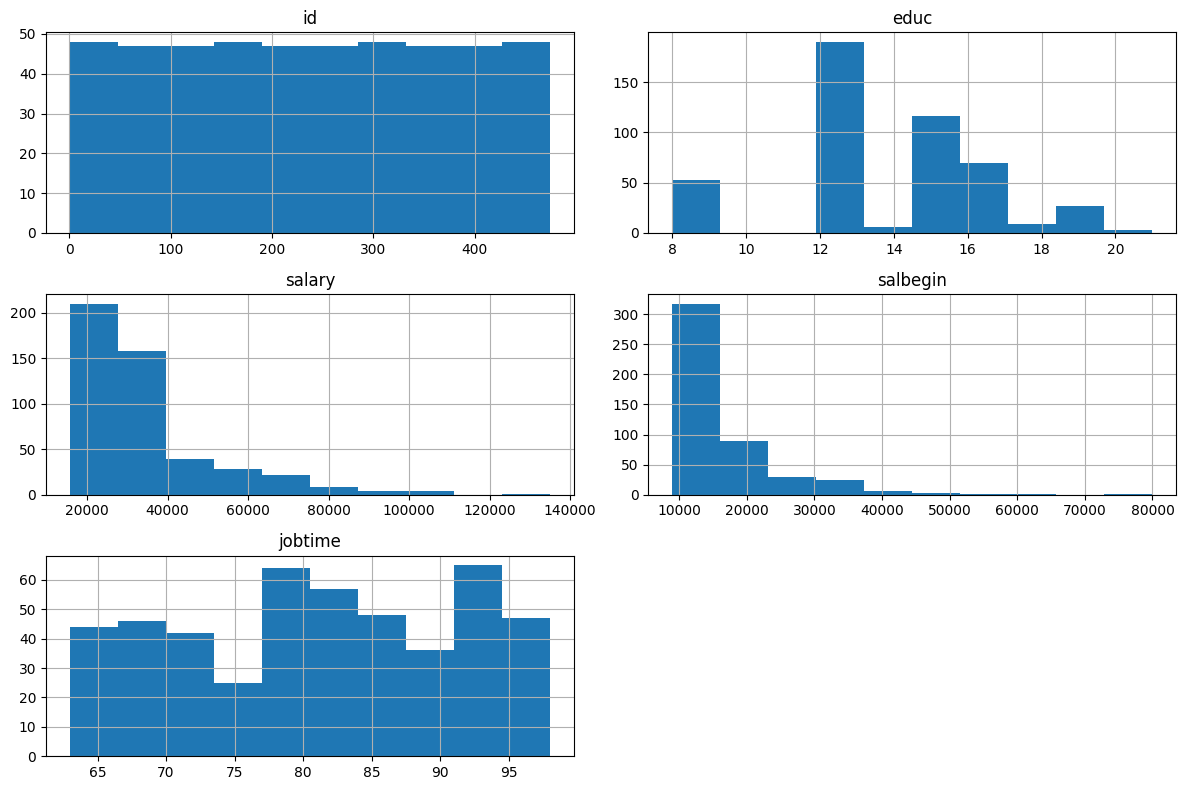

In [11]:
# Histograms for all numerical columns
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Task 9: Correlation Analysis

In [12]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
corr = numeric_df.corr()

corr

,id,educ,salary,salbegin,jobtime
id,1.000000,-0.057212,-0.095544,0.007812,-0.998186
educ,-0.057212,1.000000,0.660559,0.633196,0.047379
salary,-0.095544,0.660559,1.000000,0.880117,0.084092
salbegin,0.007812,0.633196,0.880117,1.000000,-0.019753
jobtime,-0.998186,0.047379,0.084092,-0.019753,1.000000


Visualize Correlation:

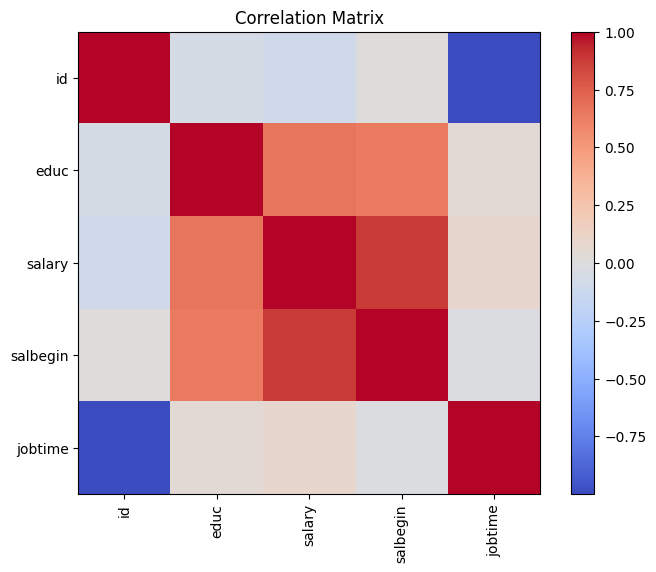

In [13]:
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

Task 10: Generate Insights Report

In [14]:
print("EDA REPORT")
print("="*50)

print("\nTotal Records:", df.shape[0])
print("Total Features:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nNumerical Summary:")
print(df.describe())

print("\nEDA Completed Successfully")

EDA REPORT

Total Records: 474
Total Features: 10

Missing Values:
id          0
gender      0
bdate       1
educ        0
jobcat      0
salary      0
salbegin    0
jobtime     0
prevexp     0
minority    0
dtype: int64

Duplicate Records:
0

Numerical Summary:
               id        educ         salary      salbegin     jobtime
count  474.000000  474.000000     474.000000    474.000000  474.000000
mean   237.500000   13.491561   34419.567511  17016.086498   81.109705
std    136.976275    2.884846   17075.661465   7870.638154   10.060945
min      1.000000    8.000000   15750.000000   9000.000000   63.000000
25%    119.250000   12.000000   24000.000000  12487.500000   72.000000
50%    237.500000   12.000000   28875.000000  15000.000000   81.000000
75%    355.750000   15.000000   36937.500000  17490.000000   90.000000
max    474.000000   21.000000  135000.000000  79980.000000   98.000000

EDA Completed Successfully
